In [ ]:
import pandas as pd
try:
  features = pd.read_csv(r'/content/dengue_features_train.csv')
  print("feature dataset loaded")
except Exception as e:
  print(f"error! {e}")

feature dataset loaded


In [ ]:
# load labels dataset
labels = pd.read_csv(r"/content/dengue_labels_train.csv")
print("label dataset loaded!")

label dataset loaded!


In [ ]:
# explore features dataset
# info
print(features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   object 
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   object 
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-null   float64
 11  rean

In [ ]:
# rename the columns
features = features.rename(
    columns=
     {'reanalysis_air_temp_k':'air_temp_k',
      'reanalysis_avg_temp_k':'avg_temp_k',
      'reanalysis_dew_point_temp_k': 'dew_temp_k',
      'reanalysis_max_air_temp_k': 'max_air_temp_k',
      'reanalysis_min_air_temp_k': 'min_air_temp_k',
      'reanalysis_precip_amt_kg_per_m2': 'precip_amt',
      'reanalysis_relative_humidity_percent': 'rel_humidity_percent',
      'reanalysis_sat_precip_amt_mm': 'sat_precip_amt',
      'reanalysis_specific_humidity_g_per_kg': 'specific_humidity',
      'reanalysis_tdtr_k': 'tdtr_k'
      }
    )

In [ ]:
features = features.rename(columns={
    'station_avg_temp_c':'avg_temp_c',
    'station_diur_temp_rng_c':'diur_temp_rng_c',
    'station_max_temp_c':'max_temp_c',
    'station_min_temp_c': 'min_temp_c'
})

In [ ]:
# make sure column names are renamed.
for cols in features.columns:
  print(cols)

city
year
weekofyear
week_start_date
ndvi_ne
ndvi_nw
ndvi_se
ndvi_sw
precipitation_amt_mm
air_temp_k
avg_temp_k
dew_temp_k
max_air_temp_k
min_air_temp_k
precip_amt
rel_humidity_percent
sat_precip_amt
specific_humidity
tdtr_k
avg_temp_c
diur_temp_rng_c
max_temp_c
min_temp_c
station_precip_mm


In [ ]:
# describe each column from dataset
print(features.describe())

              year   weekofyear      ndvi_ne      ndvi_nw      ndvi_se  \
count  1456.000000  1456.000000  1262.000000  1404.000000  1434.000000   
mean   2001.031593    26.503434     0.142294     0.130553     0.203783   
std       5.408314    15.019437     0.140531     0.119999     0.073860   
min    1990.000000     1.000000    -0.406250    -0.456100    -0.015533   
25%    1997.000000    13.750000     0.044950     0.049217     0.155087   
50%    2002.000000    26.500000     0.128817     0.121429     0.196050   
75%    2005.000000    39.250000     0.248483     0.216600     0.248846   
max    2010.000000    53.000000     0.508357     0.454429     0.538314   

           ndvi_sw  precipitation_amt_mm   air_temp_k   avg_temp_k  \
count  1434.000000           1443.000000  1446.000000  1446.000000   
mean      0.202305             45.760388   298.701852   299.225578   
std       0.083903             43.715537     1.362420     1.261715   
min      -0.063457              0.000000   294.635714

In [ ]:
# print null values
print("Null values")
print(features.isnull().sum())
print("total null values: ", features.isnull().sum().sum())
print("\ntotal duplicate values: ", features.duplicated().sum())

Null values
city                      0
year                      0
weekofyear                0
week_start_date           0
ndvi_ne                 194
ndvi_nw                  52
ndvi_se                  22
ndvi_sw                  22
precipitation_amt_mm     13
air_temp_k               10
avg_temp_k               10
dew_temp_k               10
max_air_temp_k           10
min_air_temp_k           10
precip_amt               10
rel_humidity_percent     10
sat_precip_amt           13
specific_humidity        10
tdtr_k                   10
avg_temp_c               43
diur_temp_rng_c          43
max_temp_c               20
min_temp_c               14
station_precip_mm        22
dtype: int64
total null values:  548

total duplicate values:  0


In [ ]:
print(features.shape)

(1456, 24)


In [ ]:
# percent null values along columns
percent_null_values = (features.isnull().sum().sum()/features.shape[0])*100
print(f"null values peercent: {percent_null_values:.2f} %")

null values peercent: 37.64 %


In [ ]:
# label dataset
print(labels.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   city         1456 non-null   object
 1   year         1456 non-null   int64 
 2   weekofyear   1456 non-null   int64 
 3   total_cases  1456 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 45.6+ KB
None


In [ ]:
#null values in label dataset
print(labels.isnull().sum())

city           0
year           0
weekofyear     0
total_cases    0
dtype: int64


In [ ]:
print(labels['total_cases'].describe())

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64


In [ ]:
# print data type of each of the feature
print(features.dtypes)

city                     object
year                      int64
weekofyear                int64
week_start_date          object
ndvi_ne                 float64
ndvi_nw                 float64
ndvi_se                 float64
ndvi_sw                 float64
precipitation_amt_mm    float64
air_temp_k              float64
avg_temp_k              float64
dew_temp_k              float64
max_air_temp_k          float64
min_air_temp_k          float64
precip_amt              float64
rel_humidity_percent    float64
sat_precip_amt          float64
specific_humidity       float64
tdtr_k                  float64
avg_temp_c              float64
diur_temp_rng_c         float64
max_temp_c              float64
min_temp_c              float64
station_precip_mm       float64
dtype: object


In [ ]:
# print week start data type column
print(features['week_start_date'].head())

0    1990-04-30
1    1990-05-07
2    1990-05-14
3    1990-05-21
4    1990-05-28
Name: week_start_date, dtype: object


In [ ]:
# 'week_start_date' is the datetime, but it is in Object data type which is wrong
# convert it into datetime
features['week_start_date'] = pd.to_datetime(features['week_start_date'])

print(features['week_start_date'].head())

0   1990-04-30
1   1990-05-07
2   1990-05-14
3   1990-05-21
4   1990-05-28
Name: week_start_date, dtype: datetime64[ns]


In [ ]:
# total dengue cases per year
# Merge features and labels DataFrames on common columns
merged_df = pd.merge(features, labels, on=['city', 'year', 'weekofyear'])

# Group by year from week_start_date and sum total_cases
cases_per_yr = merged_df.groupby(merged_df['week_start_date'].dt.year)['total_cases'].sum()
cases_per_yr = cases_per_yr.reset_index()
print(cases_per_yr)

    week_start_date  total_cases
0              1990          866
1              1991         2801
2              1992         2371
3              1993         1156
4              1994         6533
5              1995         1333
6              1996          855
7              1997         1454
8              1998         4595
9              1999         1633
10             2000          496
11             2001         1477
12             2002         1156
13             2003         1063
14             2004         1248
15             2005         2116
16             2006          986
17             2007         2334
18             2008          907
19             2009          324
20             2010          223


In [ ]:
# import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

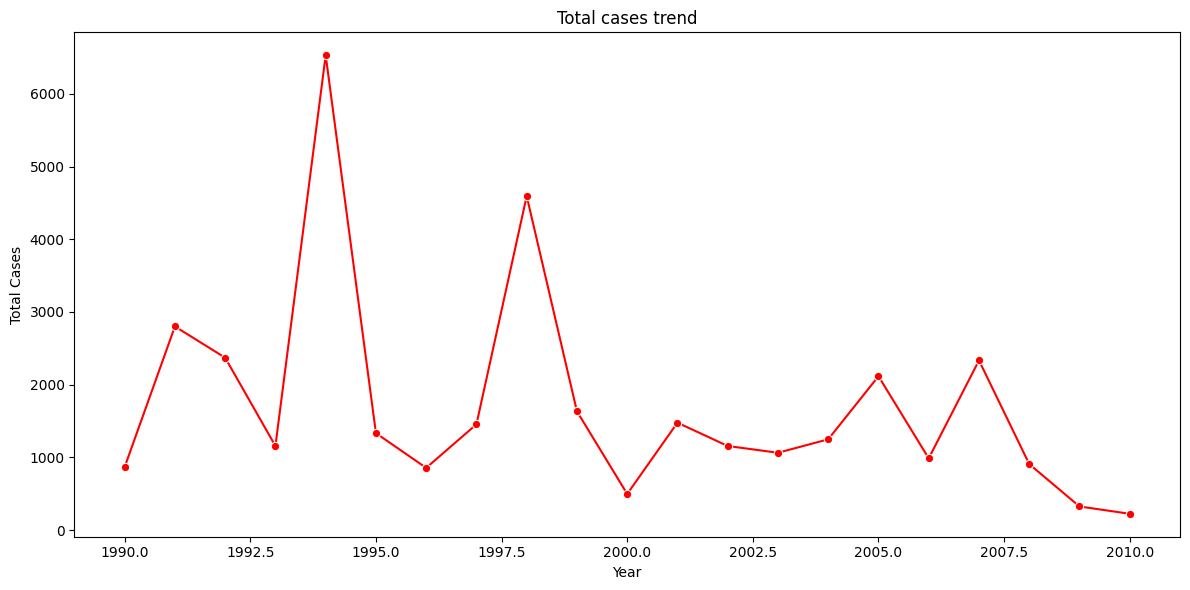

In [ ]:
# plot line graph
plt.figure(figsize=(12,6))
sns.lineplot(x=cases_per_yr['week_start_date'], y=cases_per_yr['total_cases'], data=cases_per_yr, marker='o', color='red')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.title("Total cases trend")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2894735604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_cases, x='city', y='total_cases', palette='viridis', color='green')


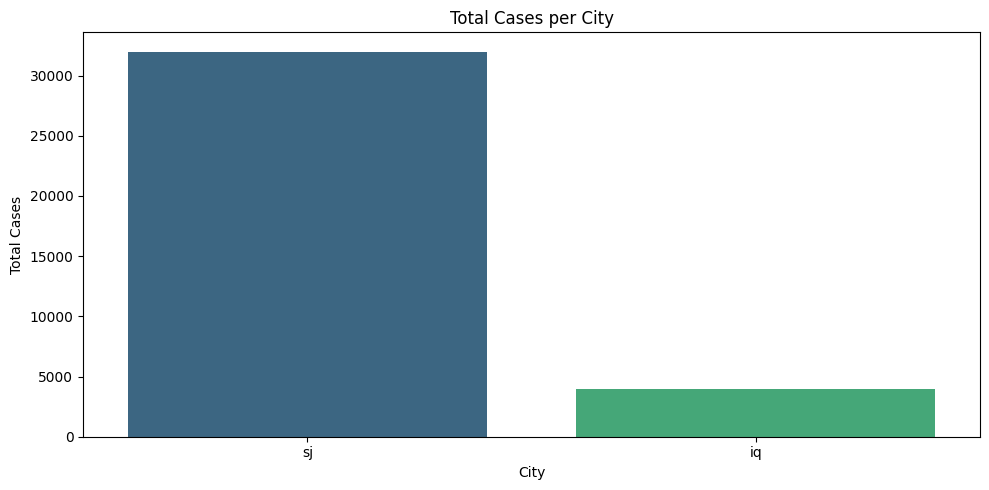

In [ ]:
# which city has highest dengue cases
city_cases = merged_df.groupby('city')['total_cases'].sum().reset_index()
city_cases = city_cases.sort_values(by='total_cases', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=city_cases, x='city', y='total_cases', palette='viridis', color='green')
plt.xlabel('City')
plt.ylabel('Total Cases')
plt.title('Total Cases per City')
plt.tight_layout()
plt.show()

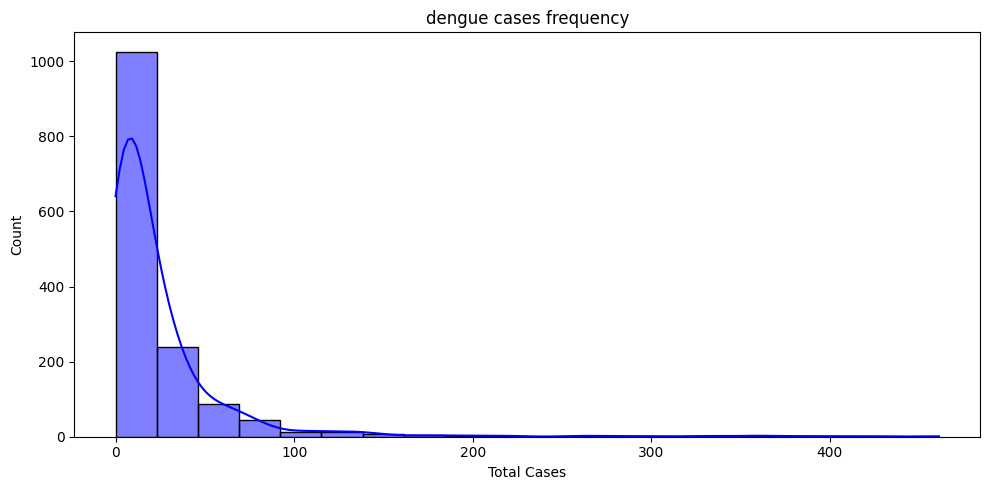

In [ ]:
# draw the histogram for total cases
plt.figure(figsize=(10,5))
sns.histplot(data=merged_df, x='total_cases', bins=20, kde=True, color='blue')
plt.xlabel('Total Cases')
plt.title('dengue cases frequency')
plt.tight_layout()
plt.show()

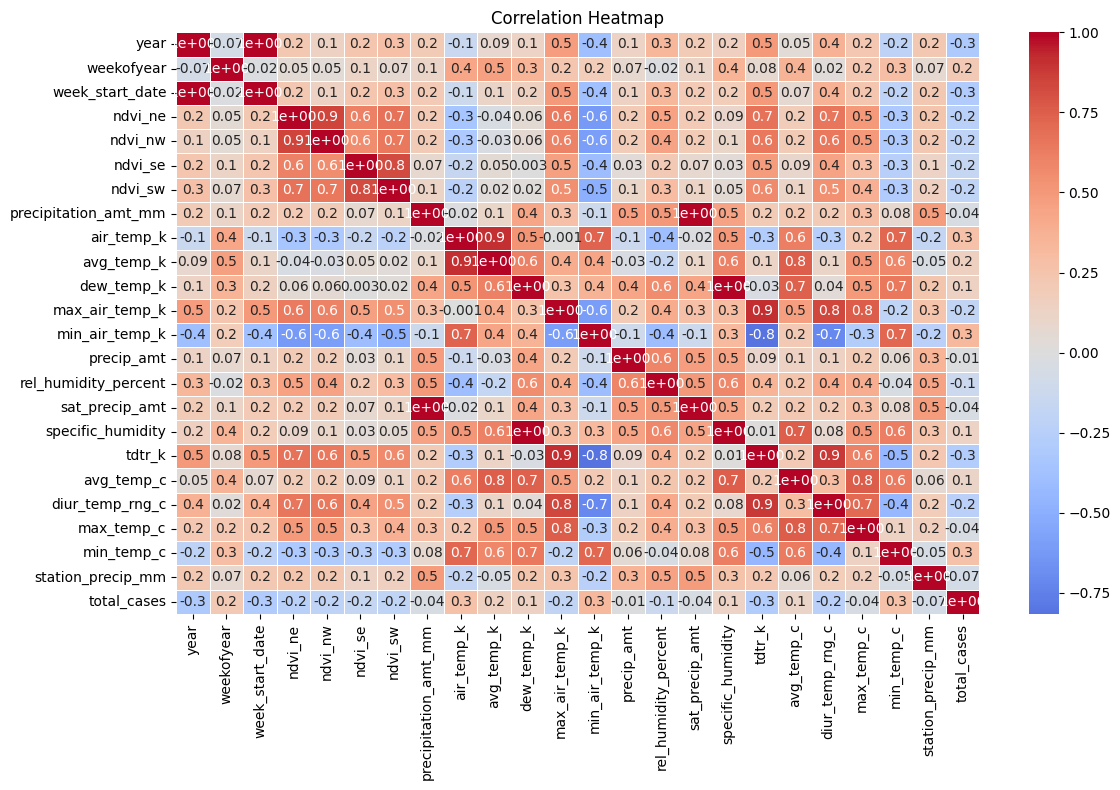

In [ ]:
# draw the heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data=merged_df.drop('city', axis=1).corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.1', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

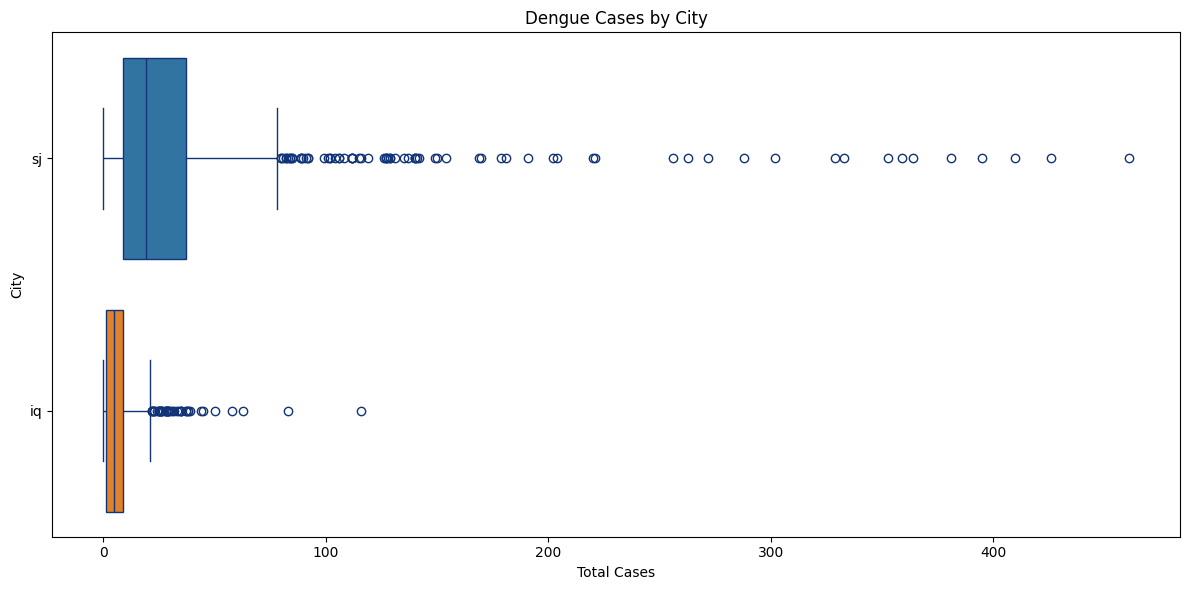

In [ ]:
# plot baxplot to view outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=merged_df, x='total_cases', y='city', linecolor="#137", hue='city')
plt.xlabel('Total Cases')
plt.ylabel('City')
plt.title('Dengue Cases by City')
plt.tight_layout()
plt.show()

In [ ]:
# import sklearn libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer

In [ ]:
for cols in merged_df:
  print(cols)

city
year
weekofyear
week_start_date
ndvi_ne
ndvi_nw
ndvi_se
ndvi_sw
precipitation_amt_mm
air_temp_k
avg_temp_k
dew_temp_k
max_air_temp_k
min_air_temp_k
precip_amt
rel_humidity_percent
sat_precip_amt
specific_humidity
tdtr_k
avg_temp_c
diur_temp_rng_c
max_temp_c
min_temp_c
station_precip_mm
total_cases


In [ ]:
print(merged_df.isnull().sum())

city                      0
year                      0
weekofyear                0
week_start_date           0
ndvi_ne                 194
ndvi_nw                  52
ndvi_se                  22
ndvi_sw                  22
precipitation_amt_mm     13
air_temp_k               10
avg_temp_k               10
dew_temp_k               10
max_air_temp_k           10
min_air_temp_k           10
precip_amt               10
rel_humidity_percent     10
sat_precip_amt           13
specific_humidity        10
tdtr_k                   10
avg_temp_c               43
diur_temp_rng_c          43
max_temp_c               20
min_temp_c               14
station_precip_mm        22
total_cases               0
dtype: int64


In [ ]:
# features and lables
from sklearn.model_selection import train_test_split

x_full = merged_df.drop('total_cases', axis=1)
y_full = merged_df['total_cases']

X_train, X_val, y_train, y_val = train_test_split(x_full, y_full, test_size=0.2, random_state=42)

In [ ]:
# separate categorical and numercial columns for preprocessing
categorical_cols = []
numercial_cols = []
for cols in X_train.columns:
  if X_train[cols].dtype == 'object':
    categorical_cols.append(cols)
  elif X_train[cols].dtype != '<M8[ns]': # Exclude datetime columns from numerical processing
    numercial_cols.append(cols)

In [ ]:
print("categorical columns: \n", categorical_cols)
print("\nNumercial columns: \n", numercial_cols)

categorical columns: 
 ['city']

Numercial columns: 
 ['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'air_temp_k', 'avg_temp_k', 'dew_temp_k', 'max_air_temp_k', 'min_air_temp_k', 'precip_amt', 'rel_humidity_percent', 'sat_precip_amt', 'specific_humidity', 'tdtr_k', 'avg_temp_c', 'diur_temp_rng_c', 'max_temp_c', 'min_temp_c', 'station_precip_mm']


In [ ]:
# preprocessing and pipeline building

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('std', StandardScaler()),
        ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numercial_cols)
    ]
)

In [ ]:
# build Model pipeline

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10))
    ]
)

xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor())
    ]
)

In [ ]:
from sklearn.model_selection import GridSearchCV

# xgb model
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5, 7]
}

# random forest model
param_grid_rf = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

In [ ]:
# set up Gridsearchcv for xgb model
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

# set up GridSearchcv for random forest model
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

In [ ]:
# fit linear model
linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('std',
                                                                   StandardScaler())]),
                                                  ['year', 'weekofyear',
                                                   'ndvi_ne', 'ndvi_nw',
                                                   'ndvi_se', 'ndvi_sw',
                                                   'precipitation_amt_mm',
                                                   'air_temp_k', 'avg_temp_k',
                                                   'dew_temp_k',
                                                   'max_air_temp_k',
                                                   'min_air_temp_k',
                                                   'precip_amt',
                                                   'rel_humidity_percent',
                                                   'sat_precip_amt',
                                                   'specific_humidity',
                                                   'tdtr_k', 'avg_temp_c',
                                                   'diur_temp_rng_c',
                                                   'max_temp_c', 'min_temp_c',
                                                   'station_precip_mm'])])),
                ('model', LinearRegression())])

In [ ]:
# fit the random forest regressor model
rf_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('std',
                                                                   StandardScaler())]),
                                                  ['year', 'weekofyear',
                                                   'ndvi_ne', 'ndvi_nw',
                                                   'ndvi_se', 'ndvi_sw',
                                                   'precipitation_amt_mm',
                                                   'air_temp_k', 'avg_temp_k',
                                                   'dew_temp_k',
                                                   'max_air_temp_k',
                                                   'min_air_temp_k',
                                                   'precip_amt',
                                                   'rel_humidity_percent',
                                                   'sat_precip_amt',
                                                   'specific_humidity',
                                                   'tdtr_k', 'avg_temp_c',
                                                   'diur_temp_rng_c',
                                                   'max_temp_c', 'min_temp_c',
                                                   'station_precip_mm'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, random_state=42))])

In [ ]:
# fit the xgb model
grid_search_xgb.fit(X_train,y_train)
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}


In [2]:
# load test dataset
import pandas as pd
test_data = pd.read_csv(r'/content/dengue_features_test.csv')
print('dataset loaded.')

dataset loaded.


In [3]:
for cols in test_data.columns:
  print(cols)

city
year
weekofyear
week_start_date
ndvi_ne
ndvi_nw
ndvi_se
ndvi_sw
precipitation_amt_mm
reanalysis_air_temp_k
reanalysis_avg_temp_k
reanalysis_dew_point_temp_k
reanalysis_max_air_temp_k
reanalysis_min_air_temp_k
reanalysis_precip_amt_kg_per_m2
reanalysis_relative_humidity_percent
reanalysis_sat_precip_amt_mm
reanalysis_specific_humidity_g_per_kg
reanalysis_tdtr_k
station_avg_temp_c
station_diur_temp_rng_c
station_max_temp_c
station_min_temp_c
station_precip_mm


In [4]:
test_data = test_data.rename(
    columns=
     {'reanalysis_air_temp_k':'air_temp_k',
      'reanalysis_avg_temp_k':'avg_temp_k',
      'reanalysis_dew_point_temp_k': 'dew_temp_k',
      'reanalysis_max_air_temp_k': 'max_air_temp_k',
      'reanalysis_min_air_temp_k': 'min_air_temp_k',
      'reanalysis_precip_amt_kg_per_m2': 'precip_amt',
      'reanalysis_relative_humidity_percent': 'rel_humidity_percent',
      'reanalysis_sat_precip_amt_mm': 'sat_precip_amt',
      'reanalysis_specific_humidity_g_per_kg': 'specific_humidity',
      'reanalysis_tdtr_k': 'tdtr_k',
      'station_avg_temp_c':'avg_temp_c',
      'station_diur_temp_rng_c':'diur_temp_rng_c',
      'station_max_temp_c':'max_temp_c',
      'station_min_temp_c': 'min_temp_c'
      }
    )

In [5]:
print("columns after renaming: \n")
for cols in test_data.columns:
  print(cols)

columns after renaming: 

city
year
weekofyear
week_start_date
ndvi_ne
ndvi_nw
ndvi_se
ndvi_sw
precipitation_amt_mm
air_temp_k
avg_temp_k
dew_temp_k
max_air_temp_k
min_air_temp_k
precip_amt
rel_humidity_percent
sat_precip_amt
specific_humidity
tdtr_k
avg_temp_c
diur_temp_rng_c
max_temp_c
min_temp_c
station_precip_mm


In [ ]:
# shape
print("shape of test dataset: ", test_data.shape)
# null values:
print("null values in test data: \n", test_data.isnull().sum())

shape of test dataset:  (416, 24)
null values in test data: 
 city                     0
year                     0
weekofyear               0
week_start_date          0
ndvi_ne                 43
ndvi_nw                 11
ndvi_se                  1
ndvi_sw                  1
precipitation_amt_mm     2
air_temp_k               2
avg_temp_k               2
dew_temp_k               2
max_air_temp_k           2
min_air_temp_k           2
precip_amt               2
rel_humidity_percent     2
sat_precip_amt           2
specific_humidity        2
tdtr_k                   2
avg_temp_c              12
diur_temp_rng_c         12
max_temp_c               3
min_temp_c               9
station_precip_mm        5
dtype: int64


In [6]:
null_cols = []
for cols in test_data.columns:
  if test_data[cols].isnull().sum() > 0:
    null_cols.append(cols)
print(null_cols)

['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'air_temp_k', 'avg_temp_k', 'dew_temp_k', 'max_air_temp_k', 'min_air_temp_k', 'precip_amt', 'rel_humidity_percent', 'sat_precip_amt', 'specific_humidity', 'tdtr_k', 'avg_temp_c', 'diur_temp_rng_c', 'max_temp_c', 'min_temp_c', 'station_precip_mm']


In [7]:
# fill null values with mean values
for cols in null_cols:
  test_data[cols].fillna(test_data[cols].mean(), inplace=True)

/tmp/ipython-input-3534369785.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data[cols].fillna(test_data[cols].mean(), inplace=True)


In [8]:
# print null values after filling
print('after filling: ')
print("null values: ", test_data.isnull().sum())

after filling: 
null values:  city                    0
year                    0
weekofyear              0
week_start_date         0
ndvi_ne                 0
ndvi_nw                 0
ndvi_se                 0
ndvi_sw                 0
precipitation_amt_mm    0
air_temp_k              0
avg_temp_k              0
dew_temp_k              0
max_air_temp_k          0
min_air_temp_k          0
precip_amt              0
rel_humidity_percent    0
sat_precip_amt          0
specific_humidity       0
tdtr_k                  0
avg_temp_c              0
diur_temp_rng_c         0
max_temp_c              0
min_temp_c              0
station_precip_mm       0
dtype: int64


In [ ]:
# predict values using
y_predict_linear = linear_model.predict(test_data)

In [ ]:
# predict values for xgboost
y_predict_xgb = grid_search_xgb.best_estimator_.predict(test_data)

In [ ]:
import numpy as np

# calculate MAE, MSE, r2 score
def evaluate_model(model, X_val, y_val):
  predictions = model.predict(X_val)
  # Ensure predictions are integers as total_cases is integer
  predictions = np.round(predictions).astype(int)
  mae = mean_absolute_error(y_val, predictions)
  mse = mean_squared_error(y_val, predictions)
  r2 = r2_score(y_val, predictions)

  return mae, mse, r2

In [ ]:
# for linear regression model

mae_linear, mse_linear, r2_linear = evaluate_model(
    model=linear_model,
    X_val=X_val,
    y_val=y_val
    )
print("Linear Regression: ")
print(f"mae: {mae_linear:.2f}")
print(f"mse: {mse_linear:.2f}")
print(f"r2: {r2_linear:.2f}")

# for xgb regressor
mae_xgb, mse_xgb, r2_xgb = evaluate_model(
    model=grid_search_xgb.best_estimator_,
    X_val=X_val,
    y_val=y_val
)
print("\nXGB Regressor: ")
print(f"mae: {mae_xgb:.2f}")
print(f"mse: {mse_xgb:.2f}")
print(f"r2: {r2_xgb:.2f}")

# Make predictions on the external test_data (dengue_features_test.csv)
y_predict_linear = linear_model.predict(test_data)
y_predict_xgb = grid_search_xgb.best_estimator_.predict(test_data)

# Round predictions to nearest integer for total_cases
y_predict_linear = np.round(y_predict_linear).astype(int)
y_predict_xgb = np.round(y_predict_xgb).astype(int)

Linear Regression: 
mae: 24.09
mse: 2702.60
r2: 0.16

XGB Regressor: 
mae: 13.05
mse: 925.73
r2: 0.71


In [ ]:
# calculate metrics for random forest regressor
mae, mse, r2 = evaluate_model(
    model=rf_model,
    X_val=X_val,
    y_val=y_val)

print("Random Forest Regressor: ")
print(f"mae: {mae_xgb:.2f}")
print(f"mse: {mse_xgb:.2f}")
print(f"r2: {r2_xgb:.2f}")

Random Forest Regressor: 
mae: 13.05
mse: 925.73
r2: 0.71


In [ ]:
# save xgb model
import joblib

joblib.dump(grid_search_xgb.best_estimator_, 'xgb_model.pkl')

['xgb_model.pkl']

In [9]:
# load saved model
import joblib
model = joblib.load('xgb_model.pkl')
if model:
  print("Model loaded successfully!")
else:
  print("falied to load model")

Model loaded successfully!


In [12]:
print(test_data.head())

  city  year  weekofyear week_start_date  ndvi_ne   ndvi_nw   ndvi_se  \
0   sj  2008          18      2008-04-29 -0.01890 -0.018900  0.102729   
1   sj  2008          19      2008-05-06 -0.01800 -0.012400  0.082043   
2   sj  2008          20      2008-05-13 -0.00150  0.126803  0.151083   
3   sj  2008          21      2008-05-20  0.12605 -0.019867  0.124329   
4   sj  2008          22      2008-05-27  0.05680  0.039833  0.062267   

    ndvi_sw  precipitation_amt_mm  air_temp_k  ...  precip_amt  \
0  0.091200                 78.60  298.492857  ...       25.37   
1  0.072314                 12.56  298.475714  ...       21.83   
2  0.091529                  3.66  299.455714  ...        4.12   
3  0.125686                  0.00  299.690000  ...        2.20   
4  0.075914                  0.76  299.780000  ...        4.36   

   rel_humidity_percent  sat_precip_amt  specific_humidity    tdtr_k  \
0             78.781429           78.60          15.918571  3.128571   
1             78.230

In [17]:
import numpy as np
# create a function to predict the "total cases" for the test dataset
# store the "city", "year", "weekofyear" and "total cases" in the dataframe

def predict_total_cases(model, test_data):
  # Make predictions for the entire test dataset
  predictions = model.predict(test_data)
  # Round predictions to nearest integer for total_cases
  predictions = np.round(predictions).astype(int)

  # Create a DataFrame to save "city", 'year', 'weekofyear' and 'total_cases'
  result = pd.DataFrame({
      'city': test_data['city'],
      'year': test_data['year'],
      'weekofyear': test_data['weekofyear'],
      'total_cases': predictions
  })
  return result

In [18]:
# call the function
output = predict_total_cases(model=model, test_data=test_data)
print(output)

    city  year  weekofyear  total_cases
0     sj  2008          18            7
1     sj  2008          19            4
2     sj  2008          20            7
3     sj  2008          21           13
4     sj  2008          22            8
..   ...   ...         ...          ...
411   iq  2013          22           10
412   iq  2013          23            2
413   iq  2013          24            1
414   iq  2013          25            4
415   iq  2013          26            3

[416 rows x 4 columns]


In [19]:
# Save the predictions to a CSV file
output.to_csv('dengue_predictions.csv', index=False)
print("Predictions saved to 'dengue_predictions.csv'")

Predictions saved to 'dengue_predictions.csv'
